PathCap数据集处理

In [1]:
# /data/ckpt/PathCap/ : data.json, images/
# data: list of dicts: {
#     "img": "27387491_13019_2016_490_Fig4_HTML_3.jpg",
#     "pmc_id": "27387491",
#     "figure_fn": "13019_2016_490_Fig4_HTML",
#     "caption": "Histological images. The tumor cells were weakly immunnoreactive for calponin."
#   }
# 请在images/ 下find img, 构建新的item: {img, text}, img: 图像的绝对路径，text: 描述, text_len: token长度
import json
import os
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

DATA_ROOT = "/data/ckpt/PathCap"
DATA_JSON_PATH = os.path.join(DATA_ROOT, "data.json")
IMAGES_DIR = os.path.join(DATA_ROOT, "images")

def load_data(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def find_image_path(images_dir, img_filename):
    for root, dirs, files in os.walk(images_dir):
        if img_filename in files:
            return os.path.abspath(os.path.join(root, img_filename))
    return None

def process_single_item(item, images_dir):
    img_filename = item.get("img")
    caption = item.get("caption", "")
    img_abs_path = find_image_path(images_dir, img_filename)
    if img_abs_path:
        text_len = len(caption.split())
        return {
            "img": img_abs_path,
            "text": caption,
            "text_len": text_len
        }
    else:
        print(f"警告: 找不到图像文件 {img_filename}")
        return None

def process_data_parallel(data, images_dir, max_workers=None):
    if max_workers is None:
        max_workers = mp.cpu_count()
    
    new_items = []
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_single_item, item, images_dir) for item in data]
        
        for future in tqdm(as_completed(futures), desc="处理数据", total=len(futures)):
            result = future.result()
            if result is not None:
                new_items.append(result)
                
    return new_items

data = load_data(DATA_JSON_PATH)
processed_data = process_data_parallel(data, IMAGES_DIR, 80)
output_path = os.path.join(DATA_ROOT, "processed_data.json")
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(processed_data, f, ensure_ascii=False, indent=2)
print(f"处理完成，共处理 {len(processed_data)} 条数据，结果已保存到 {output_path}")

处理数据: 100%|██████████| 223169/223169 [13:11<00:00, 281.83it/s]


处理完成，共处理 223169 条数据，结果已保存到 /data/ckpt/PathCap/processed_data.json


将pathgen-1.6M的数据转为同样的方式

In [ ]:
# /nvme/pathgen/patch_pairs/ 路径下 {slide_id}/ 下 若干 xxx.png xxx.txt, 这里的xxx有很多个
# 保存json: img, text, text_len, slide_id
import os
import json
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

ROOT_PATH = "/nvme/pathgen/patch_pairs"

def process_single_slide(slide_id, slide_path):
    items = []
    try:
        files = os.listdir(slide_path)
        png_files = [f for f in files if f.endswith('.png')]
        for png_file in png_files:
            txt_file = png_file.replace('.png', '.txt')
            txt_path = os.path.join(slide_path, txt_file)
            if os.path.exists(txt_path):
                with open(txt_path, 'r', encoding='utf-8') as f:
                    text = f.read().strip()
                img_path = os.path.abspath(os.path.join(slide_path, png_file))
                text_len = len(text.split())
                item = {
                    "img": img_path,
                    "text": text,
                    "text_len": text_len,
                    "slide_id": slide_id
                }
                items.append(item)
    except Exception as e:
        print(f"处理slide {slide_id}时出错: {e}")
    return items

def process_all_slides_parallel(root_path, max_workers=None):
    if max_workers is None:
        max_workers = mp.cpu_count()
    
    all_items = []
    slide_ids = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_slide = {
            executor.submit(process_single_slide, slide_id, os.path.join(root_path, slide_id)): slide_id 
            for slide_id in slide_ids
        }
        for future in tqdm(as_completed(future_to_slide), total=len(slide_ids), desc="处理slides"):
            slide_id = future_to_slide[future]
            try:
                items = future.result()
                all_items.extend(items)
            except Exception as e:
                print(f"处理slide {slide_id}时出错: {e}")
    
    return all_items

# 执行处理
all_data = process_all_slides_parallel(ROOT_PATH, 8)
output_path = "/nvme/pathgen/processed_data.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)
print(f"处理完成，共处理 {len(all_data)} 条数据，结果已保存到 {output_path}")

整理 器官 to slide_ids dict

In [7]:
# /data/pathgen/project_id2path_list.json
# 是一个list, 每一项是dict, organ : [path1, path2, path3, ...], 每个path可以通过.split(/)[-1].split('-01Z-00-DX1.')[0]
# 断言 -01Z-00-DX1. 在path中存在
import json
import os

def convert_and_save_organ_slide_ids(json_path, outpath):
    with open(json_path, 'r') as f:
        project_id2path_list = json.load(f)
    organ2slide_ids = {}
    for organ, paths in project_id2path_list.items():
        slide_ids = []
        for path in paths:
            assert '-01Z-00-DX1.' in path, f"Path {path} does not contain '-01Z-00-DX1.'"
            slide_id = path.split('/')[-1].split('-01Z-00-DX1.')[0]
            slide_ids.append(slide_id)
        organ2slide_ids[organ] = slide_ids
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    with open(outpath, 'w') as f:
        json.dump(organ2slide_ids, f, indent=2)
    print(f"数据已保存到 {outpath}")
    return organ2slide_ids

json_path = '/data/pathgen/project_id2path_list.json'
outpath = '/data/ljd/VLM-R1/dataset/pathgen_organ2slide_ids.json'
organ2slide_ids = convert_and_save_organ_slide_ids(json_path, outpath)


数据已保存到 /data/ljd/VLM-R1/dataset/pathgen_organ2slide_ids.json


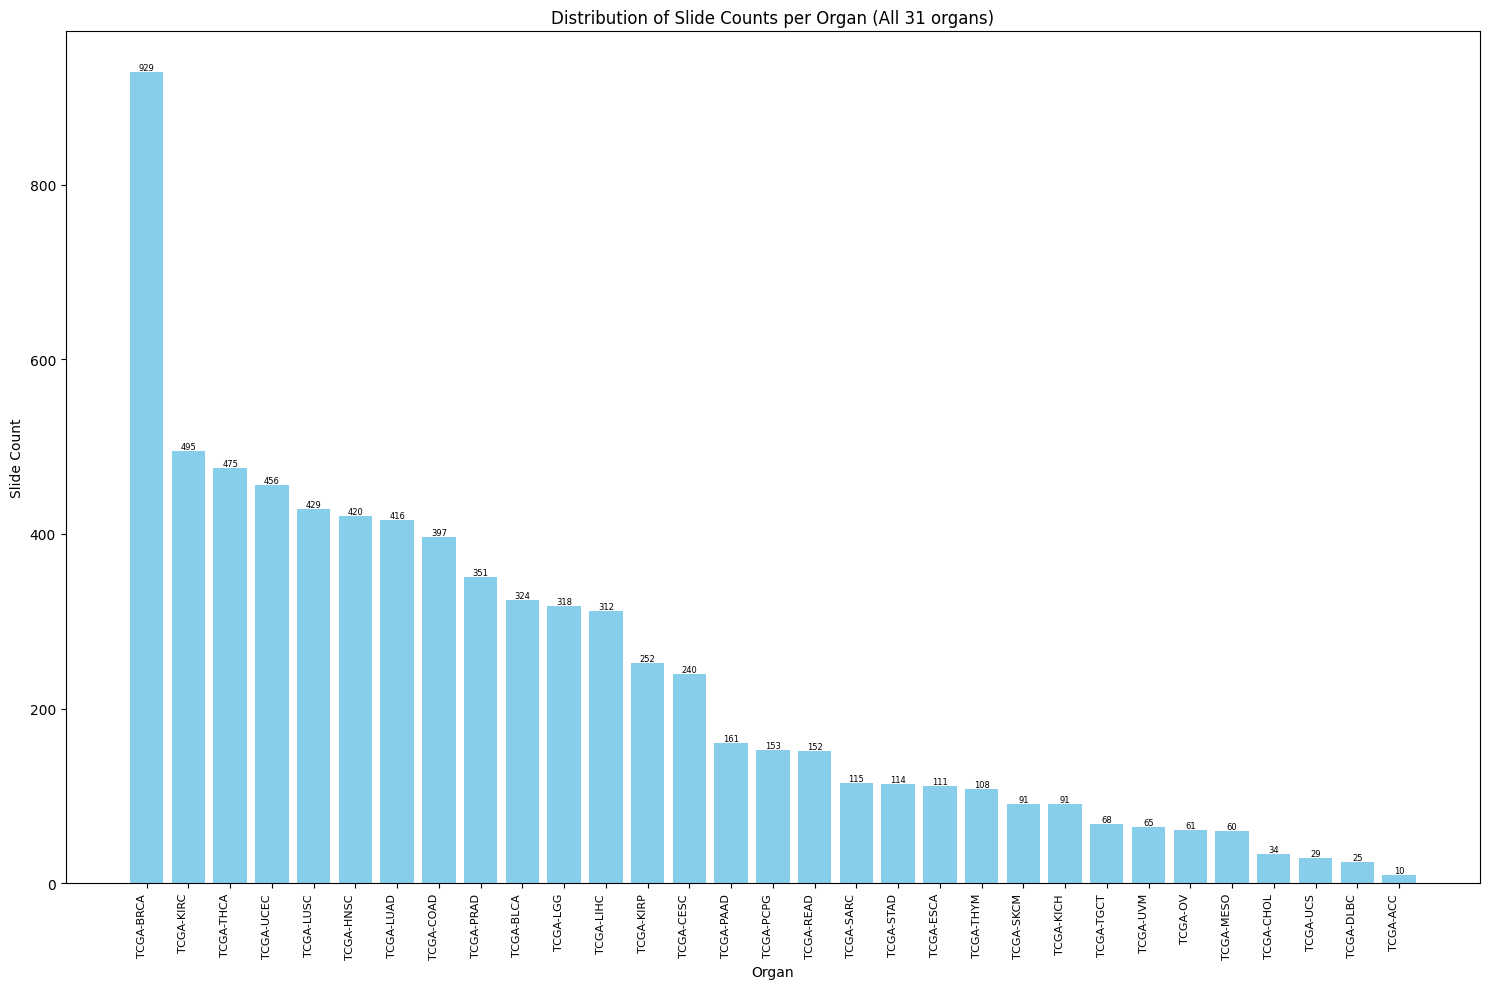

总共有 31 个 organs
Slide总数: 7262

各器官slide数量（按数量降序排列）:
TCGA-BRCA: 929
TCGA-KIRC: 495
TCGA-THCA: 475
TCGA-UCEC: 456
TCGA-LUSC: 429
TCGA-HNSC: 420
TCGA-LUAD: 416
TCGA-COAD: 397
TCGA-PRAD: 351
TCGA-BLCA: 324
TCGA-LGG: 318
TCGA-LIHC: 312
TCGA-KIRP: 252
TCGA-CESC: 240
TCGA-PAAD: 161
TCGA-PCPG: 153
TCGA-READ: 152
TCGA-SARC: 115
TCGA-STAD: 114
TCGA-ESCA: 111
TCGA-THYM: 108
TCGA-SKCM: 91
TCGA-KICH: 91
TCGA-TGCT: 68
TCGA-UVM: 65
TCGA-OV: 61
TCGA-MESO: 60
TCGA-CHOL: 34
TCGA-UCS: 29
TCGA-DLBC: 25
TCGA-ACC: 10

统计信息已保存到 /data/ljd/VLM-R1/dataset/organ_statistics.txt


In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_organ_slide_distribution(organ2slide_ids, txt_output_path=None):
    organ_slide_counts = {organ: len(slide_ids) for organ, slide_ids in organ2slide_ids.items()}
    sorted_organs = sorted(organ_slide_counts.items(), key=lambda x: x[1], reverse=True)
    organs = [item[0] for item in sorted_organs]
    counts = [item[1] for item in sorted_organs]
    plt.figure(figsize=(15, 10))
    bars = plt.bar(range(len(organs)), counts, color='skyblue')
    plt.xlabel('Organ')
    plt.ylabel('Slide Count')
    plt.title('Distribution of Slide Counts per Organ (All {} organs)'.format(len(organs)))
    plt.xticks(range(len(organs)), organs, rotation=90, ha='right', fontsize=8)
    for i, (organ, count) in enumerate(zip(organs, counts)):
        # if count > max(counts) * 0.05:  # 只标注数量大于最大值5%的柱子
        plt.text(i, count, str(count), ha='center', va='bottom', fontsize=6)
    
    # 调整布局防止标签被截断
    plt.tight_layout()
    
    # 显示图表
    plt.show()
    
    # 打印统计信息
    total_slides = sum(counts)
    print(f"总共有 {len(organ2slide_ids)} 个 organs")
    print(f"Slide总数: {total_slides}")
    print("\n各器官slide数量（按数量降序排列）:")
    for organ, count in sorted_organs:
        print(f"{organ}: {count}")
    
    # 如果指定了输出路径，则将统计信息保存到txt文件
    if txt_output_path:
        with open(txt_output_path, 'w', encoding='utf-8') as f:
            f.write(f"总共有 {len(organ2slide_ids)} 个 organs\n")
            f.write(f"Slide总数: {total_slides}\n")
            f.write("\n各器官slide数量（按数量降序排列）:\n")
            for organ, count in sorted_organs:
                f.write(f"{organ}: {count}\n")
        print(f"\n统计信息已保存到 {txt_output_path}")

# 使用示例
plot_organ_slide_distribution(organ2slide_ids, '/data/ljd/VLM-R1/dataset/organ_statistics.txt')

划分训练/测试集, 9:1 按照每个器官

In [10]:
# 按照器官, 对slide进行随机的划分: 9:1, 作为train和eval
# 直接对organ2slide_ids 进行划分, 保存到/data/ljd/VLM-R1/dataset/pathgen_slide_train_test_divide.json
import json
import random
import numpy as np
from tqdm import tqdm

def divide_train_test_by_organ(organ2slide_ids, train_ratio=0.9, random_seed=42):
    """
    按照器官对slide进行随机划分，生成训练集和测试集
    
    Args:
        organ2slide_ids (dict): organ到slide_ids的映射字典
        train_ratio (float): 训练集占比，默认为0.9
        random_seed (int): 随机种子，确保结果可重现
    
    Returns:
        dict: 包含train和test划分结果的字典
    """
    # 设置随机种子以确保结果可重现
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    # 初始化训练集和测试集
    train_slides = []
    test_slides = []
    
    # 对每个器官分别进行划分
    for organ, slide_ids in tqdm(organ2slide_ids.items(), desc="划分训练/测试集"):
        # 随机打乱slide_ids
        shuffled_slide_ids = slide_ids.copy()
        random.shuffle(shuffled_slide_ids)
        
        # 计算训练集大小
        train_size = int(len(shuffled_slide_ids) * train_ratio)
        
        # 划分训练集和测试集
        organ_train_slides = shuffled_slide_ids[:train_size]
        organ_test_slides = shuffled_slide_ids[train_size:]
        
        # 添加到总的训练集和测试集中
        train_slides.extend(organ_train_slides)
        test_slides.extend(organ_test_slides)
        
        # 打印每个器官的划分情况
        print(f"{organ}: 总计{len(slide_ids)}张, 训练集{len(organ_train_slides)}张, 测试集{len(organ_test_slides)}张")
    
    # 构建结果字典
    division_result = {
        "train": train_slides,
        "test": test_slides,
        "train_count": len(train_slides),
        "test_count": len(test_slides)
    }
    
    return division_result

def save_division_result(division_result, output_path):
    """
    保存划分结果到JSON文件
    
    Args:
        division_result (dict): 划分结果字典
        output_path (str): 输出文件路径
    """
    # 保存到文件
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(division_result, f, ensure_ascii=False, indent=2)
    
    print(f"划分结果已保存到 {output_path}")
    print(f"训练集数量: {division_result['train_count']}")
    print(f"测试集数量: {division_result['test_count']}")
    print(f"训练集占比: {division_result['train_count'] / (division_result['train_count'] + division_result['test_count']):.2%}")

# 使用示例
division_result = divide_train_test_by_organ(organ2slide_ids)
save_division_result(division_result, '/data/ljd/VLM-R1/dataset/pathgen_slide_train_test_divide.json')

划分训练/测试集: 100%|██████████| 31/31 [00:00<00:00, 11426.61it/s]

TCGA-LUSC: 总计429张, 训练集386张, 测试集43张
TCGA-LUAD: 总计416张, 训练集374张, 测试集42张
TCGA-LGG: 总计318张, 训练集286张, 测试集32张
TCGA-UVM: 总计65张, 训练集58张, 测试集7张
TCGA-BLCA: 总计324张, 训练集291张, 测试集33张
TCGA-COAD: 总计397张, 训练集357张, 测试集40张
TCGA-PRAD: 总计351张, 训练集315张, 测试集36张
TCGA-SKCM: 总计91张, 训练集81张, 测试集10张
TCGA-THYM: 总计108张, 训练集97张, 测试集11张
TCGA-STAD: 总计114张, 训练集102张, 测试集12张
TCGA-UCEC: 总计456张, 训练集410张, 测试集46张
TCGA-BRCA: 总计929张, 训练集836张, 测试集93张
TCGA-CESC: 总计240张, 训练集216张, 测试集24张
TCGA-THCA: 总计475张, 训练集427张, 测试集48张
TCGA-KIRP: 总计252张, 训练集226张, 测试集26张
TCGA-KICH: 总计91张, 训练集81张, 测试集10张
TCGA-MESO: 总计60张, 训练集54张, 测试集6张
TCGA-PCPG: 总计153张, 训练集137张, 测试集16张
TCGA-HNSC: 总计420张, 训练集378张, 测试集42张
TCGA-ESCA: 总计111张, 训练集99张, 测试集12张
TCGA-SARC: 总计115张, 训练集103张, 测试集12张
TCGA-UCS: 总计29张, 训练集26张, 测试集3张
TCGA-PAAD: 总计161张, 训练集144张, 测试集17张
TCGA-TGCT: 总计68张, 训练集61张, 测试集7张
TCGA-READ: 总计152张, 训练集136张, 测试集16张
TCGA-DLBC: 总计25张, 训练集22张, 测试集3张
TCGA-LIHC: 总计312张, 训练集280张, 测试集32张
TCGA-ACC: 总计10张, 训练集9张, 测试集1张
TCGA-CHOL: 总计34张, 训练集30张, 测试集4张
TCGA-OV: 总计61张, 训

自然图像数据： llava pretraine dataset 随机选择200k 个数据; instruction dataset 随机选择20k 个数据; 

In [14]:
import json
import os
import random
from tqdm import tqdm

json_path = '/data/ljd/VLM-R1/dataset/LLaVA-CC3M-Pretrain-595K/metadata.json'
images_dir = '/data/ljd/VLM-R1/dataset/LLaVA-CC3M-Pretrain-595K/images'
with open(json_path, 'r') as f:
    data = json.load(f)
print(f"原始数据总量: {len(data)}")
random.seed(42)  # 设置随机种子确保结果可重现
selected_data = random.sample(data, 200000)
print(f"随机选择数据量: {len(selected_data)}")
processed_data = []
for item in tqdm(selected_data, desc="处理数据"):
    image_filename = item.get("image")
    caption = item.get("caption", "")
    
    # 构建图像绝对路径
    img_abs_path = os.path.join(images_dir, image_filename)
    
    # 计算文本长度
    text_len = len(caption.split())
    
    # 构建新的数据项
    processed_item = {
        "img": img_abs_path,
        "text": caption,
        "text_len": text_len
    }
    
    processed_data.append(processed_item)

output_path = f'/data/ljd/VLM-R1/dataset/llavacaption_pair_{len(processed_data)}.json'

os.makedirs(os.path.dirname(output_path), exist_ok=True)
# 保存处理后的数据
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(processed_data, f, ensure_ascii=False, indent=2)

print(f"处理完成，共处理 {len(processed_data)} 条数据，结果已保存到 {output_path}")

# 显示示例数据
print("示例数据:")
print(processed_data[0])

原始数据总量: 595375
随机选择数据量: 200000


处理数据: 100%|██████████| 200000/200000 [00:00<00:00, 358755.98it/s]


处理完成，共处理 200000 条数据，结果已保存到 /data/ljd/VLM-R1/dataset/llavacaption_pair_200000.json
示例数据:
{'img': '/data/ljd/VLM-R1/dataset/LLaVA-CC3M-Pretrain-595K/images/GCC_train_002664002.jpg', 'text': 'sharing the gift of a family trip .', 'text_len': 8}


In [30]:
import json

instruct_json_path = '/data/ljd/VLM-R1/dataset/sft/llava_instruct_80k.json'
data = json.load(open(instruct_json_path, 'r'))
# /data/ljd/VLM-R1/ckpt/vlm-r1-rec-dataset/train2014/COCO_train2014_{image}
print(len(data))
print(data[0])
print(data[0].keys())
instructs = []
for item in data:
    image = f"/data/ljd/VLM-R1/ckpt/vlm-r1-rec-dataset/train2014/COCO_train2014_{item['image']}"
    if not os.path.exists(image): 
        print(image)
        continue
    instructs.append({
        "image": image,
        'conversations': item['conversations'],
    })
print(len(instructs))
# 随机选择20k
import random
random.shuffle(instructs)
instructs = instructs[:20000]
savepath = f'/data/ljd/VLM-R1/dataset/sft/llava_instruct_{len(instructs)}.json'
json.dump(instructs, open(savepath, 'w'), indent=4)

80000
{'id': '000000379143', 'image': '000000379143.jpg', 'conversations': [{'from': 'human', 'value': 'What is the man doing in the back of the pickup truck?\n<image>'}, {'from': 'gpt', 'value': 'The man is sitting on top of piled objects or belongings loaded into the back of a pickup truck.'}, {'from': 'human', 'value': 'Is the man holding anything in his hands?'}, {'from': 'gpt', 'value': 'Yes, the man is holding a beer in his hand while sitting on top of the objects in the back of the pickup truck.'}, {'from': 'human', 'value': 'What color is the pickup truck?'}, {'from': 'gpt', 'value': 'The pickup truck is white.'}, {'from': 'human', 'value': 'Is the man sitting or standing?'}, {'from': 'gpt', 'value': 'The man is sitting on top of the piled objects in the back of the pickup truck.'}, {'from': 'human', 'value': 'What could be the possible reasons for the man sitting on top of the possessions in the back of the pickup truck?'}, {'from': 'gpt', 'value': "There could be several reas

In [24]:
from tqdm import tqdm
import json

instruct_json_path = '/data/pathgen/PathGen-Instruct.json'
data = json.load(open(instruct_json_path))
instructions_open = []
instructions_close = []
for item in tqdm(data, total=len(data)):
    if not "-01Z-00-DX1." in item['image']: 
        continue
    slide_id = item['image'].split('-01Z-00-DX1.')[0]
    x, y = item['position']
    img_path = f'/nvme/pathgen/patch_pairs/{slide_id}/{slide_id}_{x}_{y}.png'
    if not os.path.exists(img_path): 
        continue
    type = item['type']
    assert type in ['OPEN', 'CLOSE']
    if type == 'OPEN':
        instructions_open.append({
        'image': img_path,
        'conversations': item['conversations'],
        'slide_id': slide_id,
    })
    else:
        instructions_close.append({
        'image': img_path,
        'conversations': item['conversations'],
        'slide_id': slide_id,
    })
print(len(instructions_open), len(instructions_close))
save_dirpath = '/data/ljd/VLM-R1/dataset/sft/'
json.dump(instructions_open, open(save_dirpath + f'pathgen_instruct_open_{len(instructions_open)}.json', 'w'), indent=4)
json.dump(instructions_close, open(save_dirpath + f'pathgen_instruct_close_{len(instructions_close)}.json', 'w'), indent=4)


100%|██████████| 200899/200899 [00:01<00:00, 192253.40it/s]


102842 93762


将多轮对话的MCQ问题改为单轮对话


In [33]:
import json
import re

def process_conversations(data):
    processed_data = []
    for item in data:
        image = item.get('image')
        slide_id = item.get('slide_id')
        conversations = item.get('conversations', [])
        i = 0
        while i < len(conversations) - 1:
            if conversations[i]['from'] == 'human' and conversations[i+1]['from'] == 'gpt':
                human_value = conversations[i]['value']
                gpt_value = conversations[i+1]['value']
                processed_question = process_question_text(human_value)
                new_item = {
                    'image': image,
                    'conversations': [
                        {
                            'from': 'human',
                            'value': processed_question
                        },
                        {
                            'from': 'gpt',
                            'value': gpt_value
                        }
                    ],
                    'slide_id': slide_id
                }
                
                processed_data.append(new_item)
                i += 2  # 移动到下一对问答
            else:
                i += 1  # 移动到下一个对话项
    
    return processed_data

def process_question_text(question_text):
    question_text = re.sub(r'<image>', '', question_text)
    pattern = r'(\n\n)(.*?)(?=\n\n|$)'
    matches = list(re.finditer(pattern, question_text))
    assert matches
    last_double_newline = matches[-1].start()
    if last_double_newline + 2 < len(question_text):
        return question_text[:last_double_newline]

input_file = '/data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_93762.json'
with open(input_file, 'r') as f:
    data = json.load(f)
print(f"原始数据量: {len(data)}")
processed_data = process_conversations(data)

print(f"处理后数据量: {len(processed_data)}")

# 保存处理后的数据
output_file = f'/data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn_{len(processed_data)}.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(processed_data, f, ensure_ascii=False, indent=2)

print(f"处理完成，结果已保存到 {output_file}")

# 显示示例数据
print("\n示例数据:")
for i in range(min(3, len(processed_data))):
    print(f"示例 {i+1}:")
    print(json.dumps(processed_data[i], indent=2, ensure_ascii=False))
    print()

原始数据量: 93762
处理后数据量: 137555
处理完成，结果已保存到 /data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn_137555.json

示例数据:
示例 1:
{
  "image": "/nvme/pathgen/patch_pairs/TCGA-LD-A66U/TCGA-LD-A66U_17120_34976.png",
  "conversations": [
    {
      "from": "human",
      "value": "What is indicated by the presence of scattered inflammatory cells in the tissue?\nA) Acute inflammation\nB) Active thrombosis\nC) Normal tissue architecture\nD) Chronic inflammation"
    },
    {
      "from": "gpt",
      "value": "A"
    }
  ],
  "slide_id": "TCGA-LD-A66U"
}

示例 2:
{
  "image": "/nvme/pathgen/patch_pairs/TCGA-R6-A6Y2/TCGA-R6-A6Y2_9568_18656.png",
  "conversations": [
    {
      "from": "human",
      "value": "Which of the following characteristics is true about the epithelial cells observed in the image?\nA) The cells near the surface are columnar in shape.\nB) The cells in the basal layer are flattened and show signs of keratinization.\nC) The cells near the surface are cuboidal and show si

In [34]:
# /data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn_137555.json
# 示例:
# {
#     "image": "/nvme/pathgen/patch_pairs/TCGA-DJ-A3UV/TCGA-DJ-A3UV_16160_13440.png",
#     "conversations": [
#       {
#         "from": "human",
#         "value": "What does the presence of darker-staining nuclei in the tissue section likely represent?\nA. Necrosis\nB. Inflammatory cells\nC. Fibroblasts\nD. Thyroid follicular cells"
#       },
#       {
#         "from": "gpt",
#         "value": "D"
#       }
#     ],
#     "slide_id": "TCGA-DJ-A3UV"
#   }
# assert image的路径存在, 而且len(conversations)=2, 且from为human和gpt, 且gpt的value为A,B,C,D,...Z中的一个
# 转为 image, question, answer, slide_id
import json
import os
import string
from tqdm import tqdm

def process_pathgen_dataset(input_file, output_file):
    """
    处理pathgen数据集，验证数据格式并转换为指定格式
    
    Args:
        input_file (str): 输入JSON文件路径
        output_file (str): 输出JSON文件路径
    """
    # 读取数据
    with open(input_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    print(f"原始数据总量: {len(data)}")
    
    # 验证并处理数据
    processed_data = []
    valid_answers = set(string.ascii_uppercase)  # A-Z
    print(f"有效答案: {valid_answers}")
    for item in tqdm(data, desc="处理数据"):
        # 检查必要字段
        if 'image' not in item or 'conversations' not in item or 'slide_id' not in item:
            print(f"跳过缺少必要字段的条目: {item}")
            continue
            
        image_path = item['image']
        conversations = item['conversations']
        slide_id = item['slide_id']
        
        # 检查image路径是否存在
        if not os.path.exists(image_path):
            print(f"跳过图像路径不存在的条目: {image_path}")
            continue
            
        # 检查conversations长度是否为2
        if len(conversations) != 2:
            print(f"跳过conversations长度不为2的条目: {len(conversations)}")
            continue
            
        # 检查对话角色是否为human和gpt
        if conversations[0]['from'] != 'human' or conversations[1]['from'] != 'gpt':
            print(f"跳过对话角色不正确的条目: {conversations[0]['from']}, {conversations[1]['from']}")
            continue
            
        # 检查gpt的回答是否为A-Z中的一个
        answer = conversations[1]['value']
        if answer not in valid_answers:
            print(f"跳过gpt回答不在A-Z范围内的条目: {answer}")
            continue
            
        # 构建新的数据项
        question = conversations[0]['value']
        new_item = {
            'image': image_path,
            'question': question,
            'answer': answer,
            'slide_id': slide_id
        }
        
        processed_data.append(new_item)
    
    # 保存处理后的数据
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(processed_data, f, ensure_ascii=False, indent=2)
    
    print(f"处理完成，共处理 {len(processed_data)} 条有效数据，结果已保存到 {output_file}")
    
    # 显示示例数据
    if processed_data:
        print("示例数据:")
        print(processed_data[0])

# 使用示例
input_file = "/data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn_137555.json"
output_file = "/data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn2synthesis.json"
process_pathgen_dataset(input_file, output_file)

原始数据总量: 137555
有效答案: {'N', 'B', 'Y', 'T', 'G', 'P', 'W', 'R', 'I', 'E', 'V', 'X', 'Q', 'M', 'K', 'O', 'F', 'L', 'J', 'D', 'S', 'H', 'A', 'Z', 'C', 'U'}


处理数据: 100%|██████████| 137555/137555 [00:00<00:00, 241331.66it/s]


处理完成，共处理 137555 条有效数据，结果已保存到 /data/ljd/VLM-R1/dataset/sft/pathgen_instruct_close_single_turn2synthesis.json
示例数据:
{'image': '/nvme/pathgen/patch_pairs/TCGA-LD-A66U/TCGA-LD-A66U_17120_34976.png', 'question': 'What is indicated by the presence of scattered inflammatory cells in the tissue?\nA) Acute inflammation\nB) Active thrombosis\nC) Normal tissue architecture\nD) Chronic inflammation', 'answer': 'A', 'slide_id': 'TCGA-LD-A66U'}


In [35]:
import os
import json

# 原始文件路径
original_file = '/data/ljd/VLM-R1/dataset/sft/pathgen_detail_desc.jsonl'

# 计算行数
with open(original_file, 'r', encoding='utf-8') as f:
    line_count = sum(1 for _ in f)

# 新文件名，包含行数
new_filename = f"pathgen_detail_desc_{line_count}.jsonl"
new_file_path = os.path.join(os.path.dirname(original_file), new_filename)

# 重命名文件
os.rename(original_file, new_file_path)
print(f"文件已重命名为: {new_file_path}")

文件已重命名为: /data/ljd/VLM-R1/dataset/sft/pathgen_detail_desc_68362.jsonl
